#Mammography Image Classification Group 20




In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 1 — Setup & Imports
# ═══════════════════════════════════════════════════════
!pip install -q scikit-learn seaborn opencv-python tqdm

from google.colab import drive
drive.mount('/content/drive')

!rm -rf /content/data
!unzip -q '/content/drive/MyDrive/breast_classification.zip' -d '/content/data'
print('Dataset extracted!')
import torch.backends.cudnn as cudnn
cudnn.benchmark = True       # A100 için en iyi convolution algoritmasını seçer
cudnn.deterministic = False  # benchmark ile
import os, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import densenet121, DenseNet121_Weights

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

ROOT      = '/content/data/breast_classification'
TRAIN_DIR = os.path.join(ROOT, 'train')
VAL_DIR   = os.path.join(ROOT, 'val')
TEST_DIR  = os.path.join(ROOT, 'test')

CLASS_NAMES = ['no_finding', 'finding']  # 0=normal, 1=abnormal
IMG_SIZE   = 512
BATCH_SIZE = 32
VALID_EXTS  = ('.png', '.jpg', '.jpeg', '.bmp')

print('Train exists:', os.path.exists(TRAIN_DIR))
print('Val exists  :', os.path.exists(VAL_DIR))
print('Test exists :', os.path.exists(TEST_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted!
Device: cuda
Train exists: True
Val exists  : True
Test exists : True


 EDA — CLASS DISTRIBUTION ANALYSIS
TRAIN: {'no_finding': 1538, 'finding': 1380}
VAL  : {'no_finding': 189, 'finding': 189}
TEST : {'no_finding': 199, 'finding': 199}

Class imbalance ratio: 1.11x
Challenge: Medical datasets are naturally imbalanced.
Solution : pos_weight in BCEWithLogitsLoss.


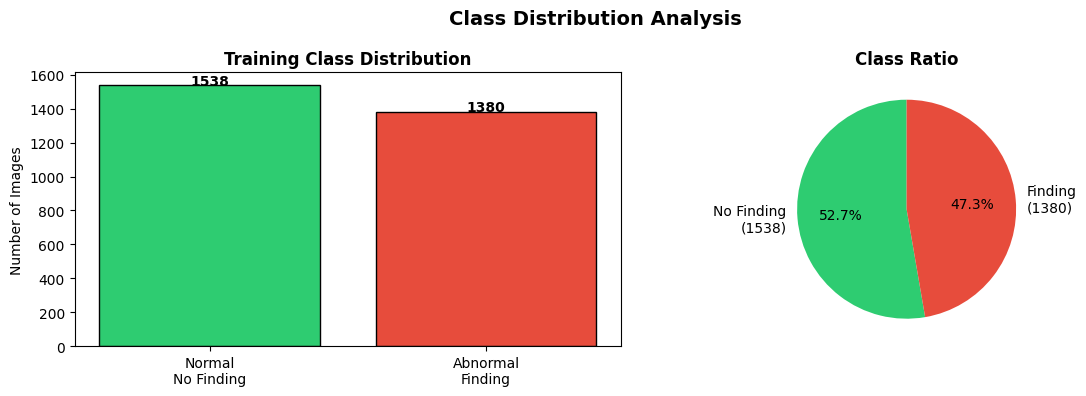

Saved: class_distribution.png


In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 2 — EDA: Class Distribution
# ═══════════════════════════════════════════════════════
print('='*55)
print(' EDA — CLASS DISTRIBUTION ANALYSIS')
print('='*55)

def count_images(folder):
    return {
        cls: len([f for f in os.listdir(os.path.join(folder, cls))
                  if f.lower().endswith(VALID_EXTS)])
        for cls in CLASS_NAMES
    }

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

print('TRAIN:', train_counts)
print('VAL  :', val_counts)
print('TEST :', test_counts)

normal_n  = train_counts['no_finding']
finding_n = train_counts['finding']
total_n   = normal_n + finding_n
print(f'\nClass imbalance ratio: {max(normal_n, finding_n)/min(normal_n, finding_n):.2f}x')
print('Challenge: Medical datasets are naturally imbalanced.')
print('Solution : pos_weight in BCEWithLogitsLoss.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bars = axes[0].bar(
    ['Normal\nNo Finding', 'Abnormal\nFinding'],
    [normal_n, finding_n],
    color=['#2ecc71', '#e74c3c'], edgecolor='black'
)
for bar, v in zip(bars, [normal_n, finding_n]):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+5,
                 str(v), ha='center', fontweight='bold')
axes[0].set_title('Training Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[1].pie(
    [normal_n, finding_n],
    labels=[f'No Finding\n({normal_n})', f'Finding\n({finding_n})'],
    colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Class Ratio', fontweight='bold')
plt.suptitle('Class Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

 EDA — SAMPLE IMAGES & HISTOGRAM ANALYSIS


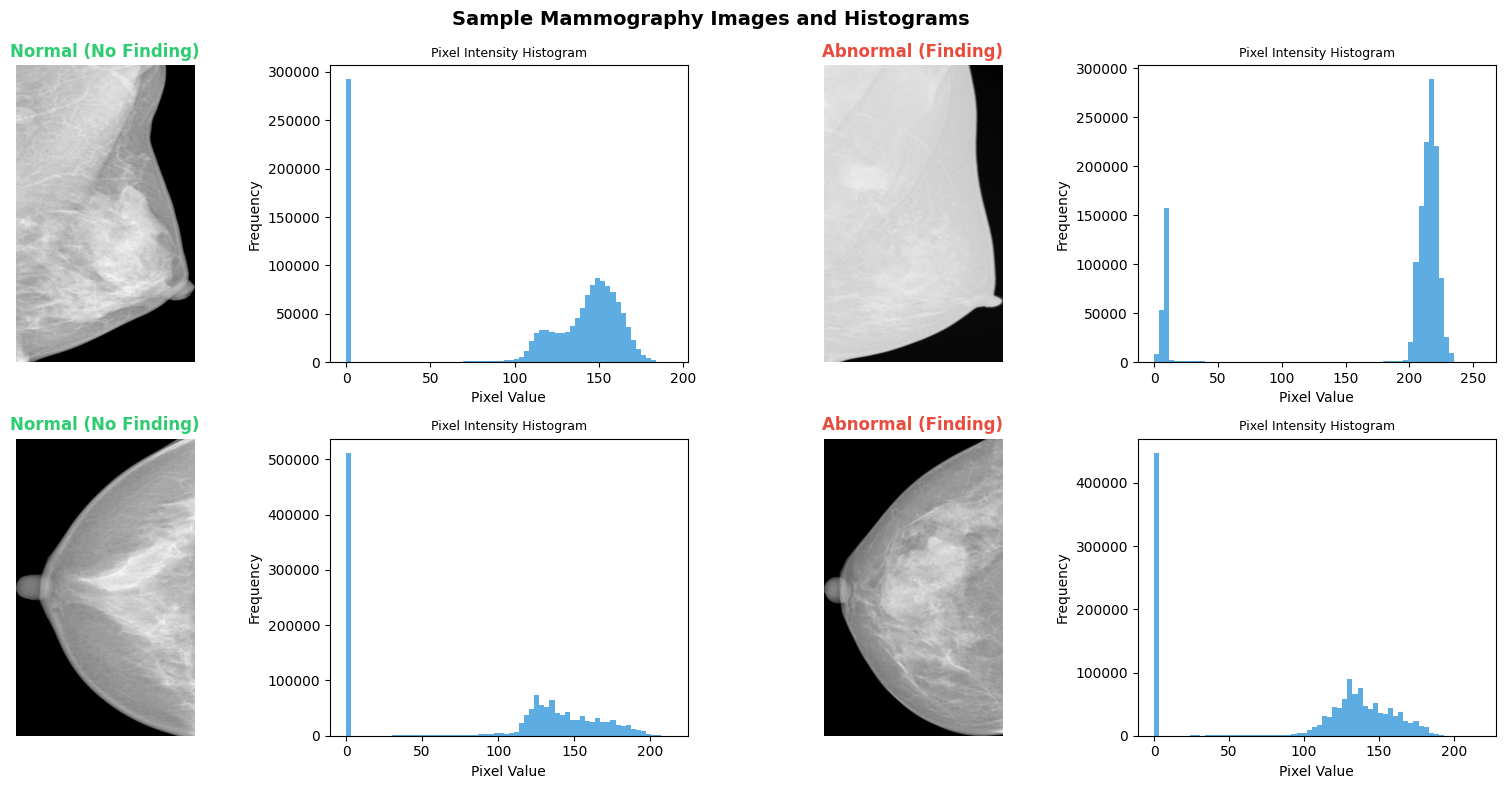

Saved: sample_images_histograms.png


In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 3 — EDA: Sample Images & Histogram Analysis
# ═══════════════════════════════════════════════════════
print('='*55)
print(' EDA — SAMPLE IMAGES & HISTOGRAM ANALYSIS')
print('='*55)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, cls in enumerate(CLASS_NAMES):
    folder  = os.path.join(TRAIN_DIR, cls)
    samples = random.sample(os.listdir(folder), 2)
    for row, fname in enumerate(samples):
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        axes[row, col*2].imshow(img, cmap='gray')
        axes[row, col*2].set_title(
            'Abnormal (Finding)' if cls=='finding' else 'Normal (No Finding)',
            color='#e74c3c' if cls=='finding' else '#2ecc71',
            fontweight='bold'
        )
        axes[row, col*2].axis('off')
        axes[row, col*2+1].hist(img.ravel(), bins=64, color='#3498db', alpha=0.8)
        axes[row, col*2+1].set_title('Pixel Intensity Histogram', fontsize=9)
        axes[row, col*2+1].set_xlabel('Pixel Value')
        axes[row, col*2+1].set_ylabel('Frequency')

plt.suptitle('Sample Mammography Images and Histograms',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_images_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_images_histograms.png')

 PREPROCESSING — CLAHE CONTRAST ENHANCEMENT


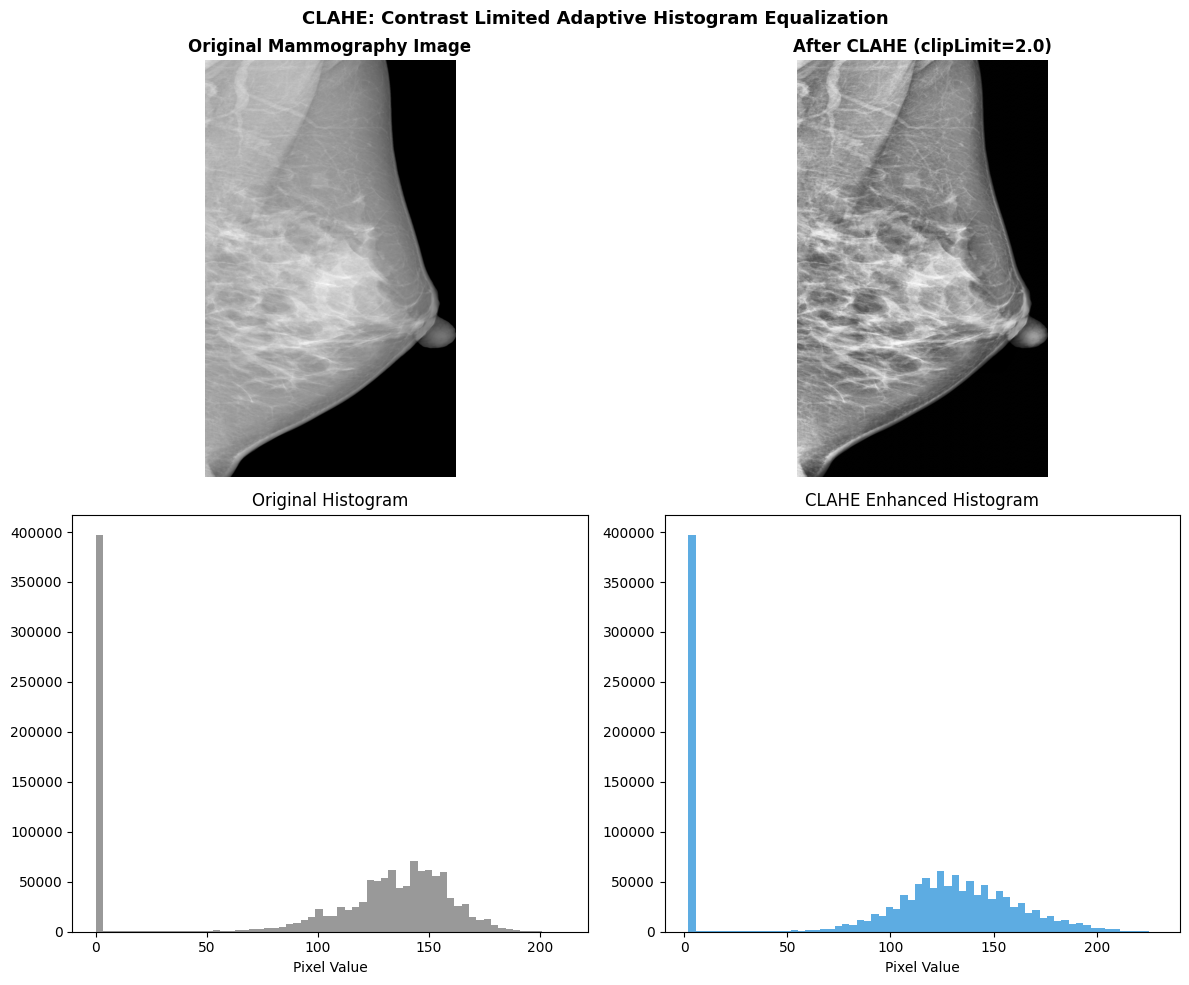

Saved: clahe_comparison.png


In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 4 — CLAHE Visualization
# ═══════════════════════════════════════════════════════
print('='*55)
print(' PREPROCESSING — CLAHE CONTRAST ENHANCEMENT')
print('='*55)

sample_path = os.path.join(
    TRAIN_DIR, 'finding',
    os.listdir(os.path.join(TRAIN_DIR, 'finding'))[0]
)
img     = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(img)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0][0].imshow(img, cmap='gray')
axes[0][0].set_title('Original Mammography Image', fontweight='bold')
axes[0][0].axis('off')
axes[0][1].imshow(enhanced, cmap='gray')
axes[0][1].set_title('After CLAHE (clipLimit=2.0)', fontweight='bold')
axes[0][1].axis('off')
axes[1][0].hist(img.ravel(), bins=64, color='gray', alpha=0.8)
axes[1][0].set_title('Original Histogram')
axes[1][0].set_xlabel('Pixel Value')
axes[1][1].hist(enhanced.ravel(), bins=64, color='#3498db', alpha=0.8)
axes[1][1].set_title('CLAHE Enhanced Histogram')
axes[1][1].set_xlabel('Pixel Value')
plt.suptitle('CLAHE: Contrast Limited Adaptive Histogram Equalization',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/clahe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: clahe_comparison.png')

In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 5 — Dataset & Transforms
# Fix: vertical flip removed (mammography anatomy asymmetric)
# ═══════════════════════════════════════════════════════
weights = DenseNet121_Weights.IMAGENET1K_V1
mean    = weights.transforms().mean
std     = weights.transforms().std

def normalize_uint8(gray):
    gray  = gray.astype(np.float32)
    p1, p99 = np.percentile(gray, (1, 99))
    gray  = np.clip(gray, p1, p99)
    gray  = (gray - gray.min()) / (gray.max() - gray.min() + 1e-8)
    return (gray * 255).astype(np.uint8)

def collect_items(root):
    items = []
    for label, cls in enumerate(CLASS_NAMES):
        folder = os.path.join(root, cls)
        for fname in sorted(os.listdir(folder)):
            if fname.lower().endswith(VALID_EXTS):
                items.append((os.path.join(folder, fname), label))
    return items

train_items = collect_items(TRAIN_DIR)
val_items   = collect_items(VAL_DIR)
test_items  = collect_items(TEST_DIR)
print(f'Train: {len(train_items)} | Val: {len(val_items)} | Test: {len(test_items)}')

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    # vertical flip REMOVED — breast anatomy is not vertically symmetric
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])
hflip_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])
rot90_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(degrees=(90,90)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

class MammoDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items     = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f'Cannot read: {path}')
        img  = normalize_uint8(img)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img  = clahe.apply(img)
        img  = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img  = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)

print('Dataset ready!')

Train: 2918 | Val: 378 | Test: 398
Dataset ready!


In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 6 — DataLoaders
# vflip_transform removed — not used in mammography
# ═══════════════════════════════════════════════════════
NUM_WORKERS = 4

train_dataset      = MammoDataset(train_items, transform=train_transform)
val_dataset        = MammoDataset(val_items,   transform=eval_transform)
test_dataset       = MammoDataset(test_items,  transform=eval_transform)
val_hflip_dataset  = MammoDataset(val_items,   transform=hflip_transform)
val_rot_dataset    = MammoDataset(val_items,   transform=rot90_transform)
test_hflip_dataset = MammoDataset(test_items,  transform=hflip_transform)
test_rot_dataset   = MammoDataset(test_items,  transform=rot90_transform)

def make_loader(ds, shuffle=False):
    return DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True
    )

train_loader      = make_loader(train_dataset,  shuffle=True)
val_loader        = make_loader(val_dataset)
test_loader       = make_loader(test_dataset)
val_hflip_loader  = make_loader(val_hflip_dataset)
val_rot_loader    = make_loader(val_rot_dataset)
test_hflip_loader = make_loader(test_hflip_dataset)
test_rot_loader   = make_loader(test_rot_dataset)

pos_weight_value = normal_n / finding_n
pos_weight       = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)
print(f'Positive class weight: {pos_weight_value:.4f}')
print('DataLoaders ready!')

Positive class weight: 1.1145
DataLoaders ready!


In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 7 — Model: DenseNet121 + Spatial Attention
# ═══════════════════════════════════════════════════════
class DenseNet121Attention(nn.Module):
    def __init__(self):
        super().__init__()
        base             = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        self.features    = base.features
        in_features      = base.classifier.in_features

        self.attention = nn.Sequential(
            nn.Conv2d(in_features, 1, kernel_size=1),
            nn.Sigmoid()
        )
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(0.45),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x             = self.features(x)
        x             = torch.relu(x)
        attention_map = self.attention(x)
        x             = x * attention_map
        x             = self.pool(x)
        x             = torch.flatten(x, 1)
        return self.classifier(x).squeeze(1)

# ← Eksik fonksiyon burada tanımlanıyor
def count_trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

model = DenseNet121Attention().to(DEVICE)

for param in model.features.parameters():
    param.requires_grad = False

print(f'Trainable params (Stage 1): {count_trainable(model):,}')
print('Model ready!')

Trainable params (Stage 1): 263,682
Model ready!


In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 8 — Training & Evaluation Functions
# Fix: Focal Loss instead of BCE — focuses on hard examples
# ═══════════════════════════════════════════════════════

class FocalLoss(nn.Module):

    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce  = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none'
        )
        pt   = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()

criterion = FocalLoss(alpha=0.75, gamma=2)
scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

def set_bn_eval(module):
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()

def train_one_epoch(model, loader, optimizer, freeze_bn=True):
    model.train()
    if freeze_bn:
        set_bn_eval(model.features)
    total_loss, all_probs, all_labels = 0.0, [], []
    for images, labels in tqdm(loader, desc='Train', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            logits = model(images)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels).astype(int)
    preds      = (all_probs >= 0.5).astype(int)
    acc        = accuracy_score(all_labels, preds)
    try:
        auc_score = roc_auc_score(all_labels, all_probs)
    except:
        auc_score = 0.5
    return total_loss / len(loader.dataset), acc, auc_score

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    for images, labels in tqdm(loader, desc='Eval', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels).astype(int)
    preds      = (all_probs >= 0.5).astype(int)
    acc        = accuracy_score(all_labels, preds)
    try:
        auc_score = roc_auc_score(all_labels, all_probs)
    except:
        auc_score = 0.5
    return total_loss / len(loader.dataset), acc, auc_score, all_probs, all_labels

print('Focal Loss + training functions ready!')

Focal Loss + training functions ready!


/tmp/ipykernel_36638/3062794239.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))


In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 9 — Stage 1: Warm-up (frozen backbone)
# Train only attention + classifier head
# ═══════════════════════════════════════════════════════
BEST_PATH = '/content/drive/MyDrive/mammo_densenet121_best.pt'

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

history = {
    'train_loss':[], 'val_loss':[],
    'train_acc':[], 'val_acc':[],
    'train_auc':[], 'val_auc':[]
}

best_val_auc    = 0.0
patience_counter = 0
PATIENCE        = 5
EPOCHS_STAGE1   = 12

print('='*55)
print(' STAGE 1: Warm-up (backbone frozen, lr=1e-3)')
print('='*55)

for epoch in range(EPOCHS_STAGE1):
    print(f'\nEpoch {epoch+1}/{EPOCHS_STAGE1}')
    train_loss, train_acc, train_auc = train_one_epoch(model, train_loader, optimizer)
    val_loss,   val_acc,   val_auc, _, _ = evaluate(model, val_loader)
    scheduler.step(val_auc)
    for k, v in zip(
        ['train_loss','val_loss','train_acc','val_acc','train_auc','val_auc'],
        [train_loss, val_loss, train_acc, val_acc, train_auc, val_auc]
    ):
        history[k].append(v)
    print(f'Train → Loss:{train_loss:.4f} Acc:{train_acc:.4f} AUC:{train_auc:.4f}')
    print(f'Val   → Loss:{val_loss:.4f} Acc:{val_acc:.4f} AUC:{val_auc:.4f}')
    if val_auc > best_val_auc:
        best_val_auc     = val_auc
        patience_counter = 0
        torch.save(model.state_dict(), BEST_PATH)
        print('  ✓ Best model saved!')
    else:
        patience_counter += 1
    if patience_counter >= PATIENCE:
        print('Early stopping.')
        break

print(f'\nStage 1 best val AUC: {best_val_auc:.4f}')

 STAGE 1: Warm-up (backbone frozen, lr=1e-3)

Epoch 1/12


Train:   0%|          | 0/92 [00:00<?, ?it/s]/tmp/ipykernel_36638/3062794239.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):


Train → Loss:0.1310 Acc:0.5141 AUC:0.5009
Val   → Loss:0.1300 Acc:0.4841 AUC:0.5009
  ✓ Best model saved!

Epoch 2/12


Train:   0%|          | 0/92 [00:00<?, ?it/s]/tmp/ipykernel_36638/3062794239.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):


Train → Loss:0.1294 Acc:0.5332 AUC:0.5402
Val   → Loss:0.1304 Acc:0.5053 AUC:0.5136
  ✓ Best model saved!

Epoch 3/12


...

Train → Loss:0.1222 Acc:0.6220 AUC:0.6599
Val   → Loss:0.1249 Acc:0.5635 AUC:0.6419
  ✓ Best model saved!

Epoch 11/12


Train:   0%|          | 0/92 [00:00<?, ?it/s]/tmp/ipykernel_36638/3062794239.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):


Train → Loss:0.1214 Acc:0.6302 AUC:0.6640
Val   → Loss:0.1235 Acc:0.6270 AUC:0.6552
  ✓ Best model saved!

Epoch 12/12


Train:   0%|          | 0/92 [00:00<?, ?it/s]/tmp/ipykernel_36638/3062794239.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):


Train → Loss:0.1211 Acc:0.6402 AUC:0.6799
Val   → Loss:0.1227 Acc:0.6270 AUC:0.6633
  ✓ Best model saved!

Stage 1 best val AUC: 0.6633


In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 10 — Stage 2: Fine-Tuning
# Fix: denseblock2 + 3 + 4 open (deeper than before)
# ═══════════════════════════════════════════════════════
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))

# Freeze all first
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze denseblock2 + 3 + 4 + norm5
for name, param in model.features.named_parameters():
    if any(x in name for x in ['denseblock2', 'denseblock3',
                                'denseblock4', 'norm5']):
        param.requires_grad = True

# Always trainable
for param in model.attention.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

print(f'Trainable params (Stage 2): {count_trainable(model):,}')

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

patience_counter = 0
PATIENCE      = 8
EPOCHS_STAGE2 = 35

print('='*55)
print(' STAGE 2: Fine-Tuning (denseblock2+3+4 open)')
print('='*55)

for epoch in range(EPOCHS_STAGE2):
    print(f'\nEpoch {epoch+1}/{EPOCHS_STAGE2}')
    train_loss, train_acc, train_auc = train_one_epoch(
        model, train_loader, optimizer
    )
    val_loss, val_acc, val_auc, _, _ = evaluate(model, val_loader)
    scheduler.step(val_auc)
    for k, v in zip(
        ['train_loss','val_loss','train_acc','val_acc','train_auc','val_auc'],
        [train_loss, val_loss, train_acc, val_acc, train_auc, val_auc]
    ):
        history[k].append(v)
    print(f'Train → Loss:{train_loss:.4f} Acc:{train_acc:.4f} AUC:{train_auc:.4f}')
    print(f'Val   → Loss:{val_loss:.4f} Acc:{val_acc:.4f} AUC:{val_auc:.4f}')
    if val_auc > best_val_auc:
        best_val_auc     = val_auc
        patience_counter = 0
        torch.save(model.state_dict(), BEST_PATH)
        print('  ✓ Best model saved!')
    else:
        patience_counter += 1
    if patience_counter >= PATIENCE:
        print('Early stopping.')
        break

print(f'\nBest overall val AUC: {best_val_auc:.4f}')

Trainable params (Stage 2): 6,181,250
 STAGE 2: Fine-Tuning (denseblock2+3+4 open)

Epoch 1/35


Train:   0%|          | 0/92 [00:00<?, ?it/s]/tmp/ipykernel_36638/3062794239.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):


Train → Loss:0.1194 Acc:0.6494 AUC:0.6791
Val   → Loss:0.1261 Acc:0.5926 AUC:0.6470

Epoch 2/35


Train:   0%|          | 0/92 [00:00<?, ?it/s]/tmp/ipykernel_36638/3062794239.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):


Train → Loss:0.1156 Acc:0.6600 AUC:0.7106
Val   → Loss:0.1240 Acc:0.6058 AUC:0.6864
  ✓ Best model saved!

Epoch 3/35


...

Train → Loss:0.0831 Acc:0.8077 AUC:0.8639
Val   → Loss:0.1368 Acc:0.6640 AUC:0.7311

Epoch 26/35


Train:   0%|          | 0/92 [00:00<?, ?it/s]/tmp/ipykernel_36638/3062794239.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):


Train → Loss:0.0823 Acc:0.8143 AUC:0.8692
Val   → Loss:0.1344 Acc:0.6693 AUC:0.7156

Epoch 27/35


Train:   0%|          | 0/92 [00:00<?, ?it/s]/tmp/ipykernel_36638/3062794239.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):


Train → Loss:0.0828 Acc:0.8139 AUC:0.8694
Val   → Loss:0.1400 Acc:0.6772 AUC:0.7244
Early stopping.

Best overall val AUC: 0.7412


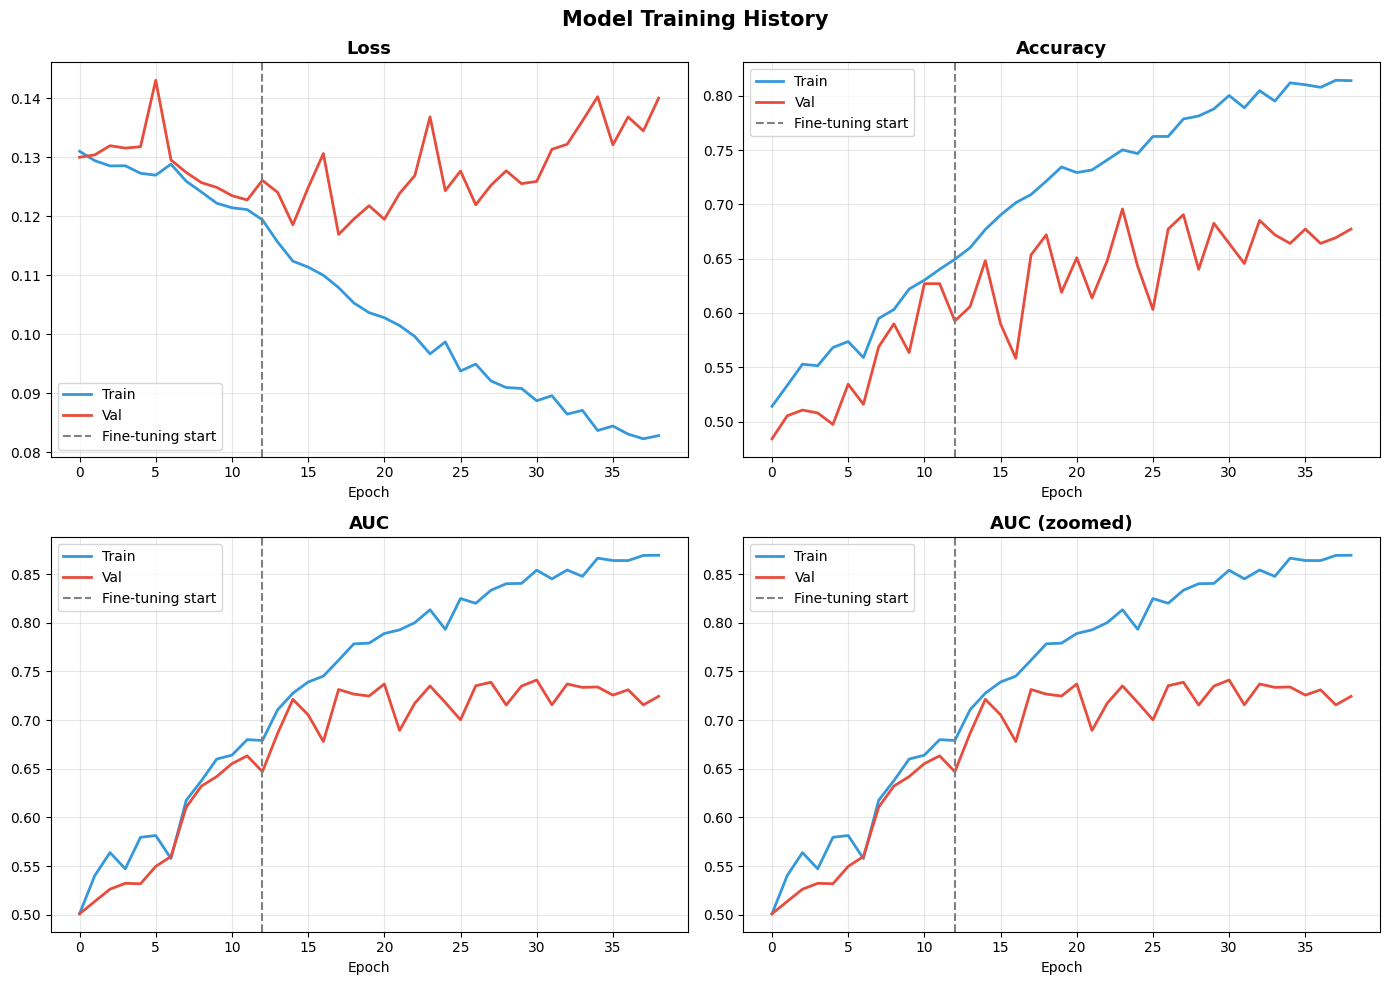

Saved: training_curves.png


In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 11 — Training Curves
# ═══════════════════════════════════════════════════════
e1 = EPOCHS_STAGE1  # fine-tuning start marker

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric, title in zip(
    axes.flatten(),
    ['loss', 'acc', 'auc', 'auc'],
    ['Loss', 'Accuracy', 'AUC', 'AUC (zoomed)']
):
    tv = history[f'train_{metric}']
    vv = history[f'val_{metric}']
    ax.plot(tv, label='Train', color='#3498db', linewidth=2)
    ax.plot(vv, label='Val',   color='#e74c3c', linewidth=2)
    ax.axvline(x=min(e1, len(tv)-1), color='gray',
               linestyle='--', label='Fine-tuning start')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Model Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

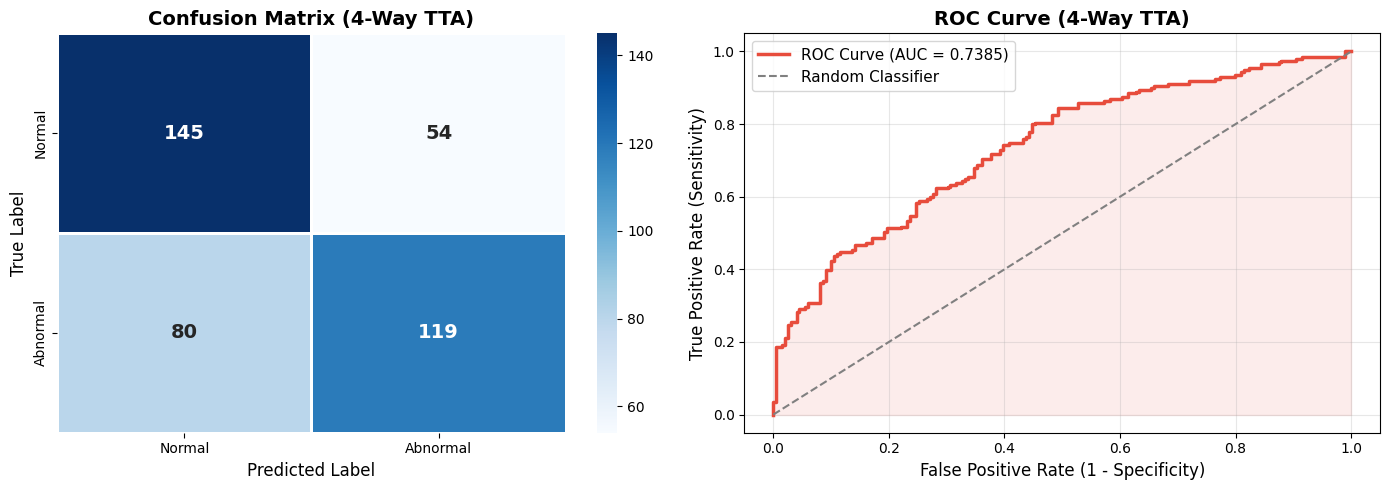

Saved: evaluation_results.png


In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 12 — Confusion Matrix + ROC Curve
# ═══════════════════════════════════════════════════════
fpr_test, tpr_test, _ = roc_curve(test_true, test_probs_tta)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', linewidths=1,
    xticklabels=['Normal', 'Abnormal'],
    yticklabels=['Normal', 'Abnormal'],
    ax=axes[0], annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title('Confusion Matrix (4-Way TTA)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

axes[1].plot(fpr_test, tpr_test, color='#e74c3c', linewidth=2.5,
             label=f'ROC Curve (AUC = {test_auc:.4f})')
axes[1].plot([0,1],[0,1],'--', color='gray', label='Random Classifier')
axes[1].fill_between(fpr_test, tpr_test, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[1].set_title('ROC Curve (4-Way TTA)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: evaluation_results.png')

In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 13 — Save & Summary
# ═══════════════════════════════════════════════════════
FINAL_PATH = '/content/drive/MyDrive/mammo_densenet121_final.pt'
torch.save(model.state_dict(), FINAL_PATH)

print('='*60)
print(' ALL OUTPUTS SAVED')
print('='*60)
print('  1. class_distribution.png       -> EDA class chart')
print('  2. sample_images_histograms.png -> Sample images + histograms')
print('  3. clahe_comparison.png         -> CLAHE before/after')
print('  4. training_curves.png          -> Loss/Accuracy/AUC plots')
print('  5. evaluation_results.png       -> Confusion Matrix + ROC')
print('  6. mammo_densenet121_best.pt    -> Best model (Drive)')
print('  7. mammo_densenet121_final.pt   -> Final model (Drive)')
print()
print('Final Test Results:')
print(f'  Accuracy    : {accuracy*100:.2f}%')
print(f'  Sensitivity : {sensitivity*100:.2f}%')
print(f'  Specificity : {specificity*100:.2f}%')
print(f'  F1-Score    : {f1:.4f}')
print(f'  AUC-ROC     : {test_auc:.4f}')

 ALL OUTPUTS SAVED
  1. class_distribution.png       -> EDA class chart
  2. sample_images_histograms.png -> Sample images + histograms
  3. clahe_comparison.png         -> CLAHE before/after
  4. training_curves.png          -> Loss/Accuracy/AUC plots
  5. evaluation_results.png       -> Confusion Matrix + ROC
  6. mammo_densenet121_best.pt    -> Best model (Drive)
  7. mammo_densenet121_final.pt   -> Final model (Drive)

Final Test Results:
  Accuracy    : 66.33%
  Sensitivity : 59.80%
  Specificity : 72.86%
  F1-Score    : 0.6398
  AUC-ROC     : 0.7385
